# B — Diagnostic Analysis

---

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
conn = sqlite3.connect('../data/olist.db')

# Rebuild the ABT
ABT_QUERY = open('../sql/queries.sql').read().split('-- ----- 2.')[1].split('-- ----- 3.')[0]
ABT_QUERY = ABT_QUERY.split('\n', 3)[-1]
abt = pd.read_sql(ABT_QUERY, conn)

# Parse dates for later use
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for c in date_cols:
    abt[c] = pd.to_datetime(abt[c])

print(f'ABT loaded: {len(abt):,} delivered orders')
print(f'Overall late rate: {abt["is_late"].mean():.1%}')

ABT loaded: 96,478 delivered orders
Overall late rate: 8.1%


## 1. Stage Decomposition

The fulfillment pipeline has 3 stages:
1. **Purchase → Approval** (internal processing)
2. **Approval → Carrier Pickup** (seller prepares & ships)
3. **Carrier Pickup → Customer Delivery** (logistics/transit)


In [ ]:
stages = ['hours_to_approval', 'hours_approval_to_carrier', 'hours_carrier_to_customer']
stage_labels = ['Purchase → Approval', 'Approval → Carrier', 'Carrier → Customer']

# Drop rows with negative/null durations
clean = abt.dropna(subset=stages).copy()
clean = clean[(clean[stages] >= 0).all(axis=1)]

# Median hours by stage
print('Median hours per stage (all orders):')
for s, label in zip(stages, stage_labels):
    print(f'  {label:<25s}  {clean[s].median():>7.1f} hrs  ({clean[s].median()/24:.1f} days)')

Median hours per stage (all orders):
  Purchase → Approval            0.3 hrs  (0.0 days)
  Approval → Carrier            44.4 hrs  (1.8 days)
  Carrier → Customer           170.6 hrs  (7.1 days)


In [3]:
# on-time vs late
comparison = clean.groupby('is_late')[stages].median()
comparison.columns = stage_labels
comparison.index = ['On time', 'Late']

print('Median hours by stage - On Time vs Late:')
print(comparison.round(1))
print()

diff = comparison.loc['Late'] - comparison.loc['On time']
print('Difference (Late - On time):')
print(diff.round(1))
print()
print(f'Biggest bottleneck: {diff.idxmax()} (+{diff.max():.0f} hrs for late orders)')

Median hours by stage - On Time vs Late:
         Purchase → Approval  Approval → Carrier  Carrier → Customer
On time                  0.3                42.8               166.4
Late                     0.4                72.4               574.2

Difference (Late - On time):
Purchase → Approval      0.1
Approval → Carrier      29.7
Carrier → Customer     407.8
dtype: float64

Biggest bottleneck: Carrier → Customer (+408 hrs for late orders)


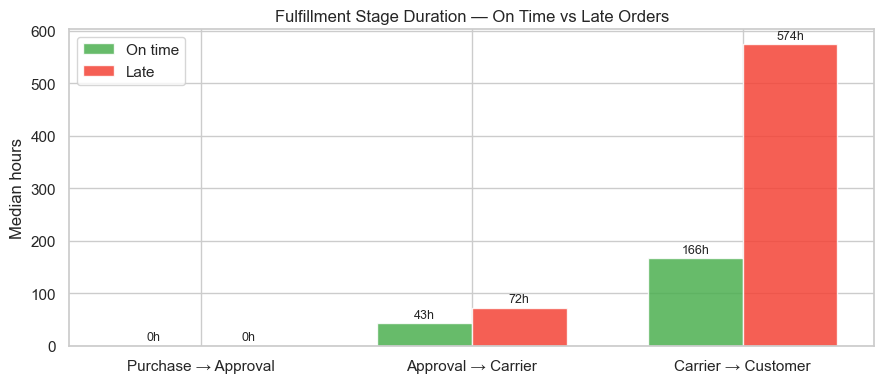

In [4]:
# Visualize the stage breakdown
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(stage_labels))
width = 0.35

ontime = comparison.loc['On time'].values
late = comparison.loc['Late'].values

bars1 = ax.bar(x - width/2, ontime, width, label='On time', color='#4CAF50', alpha=0.85)
bars2 = ax.bar(x + width/2, late, width, label='Late', color='#F44336', alpha=0.85)

ax.set_ylabel('Median hours')
ax.set_title('Fulfillment Stage Duration — On Time vs Late Orders')
ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{bar.get_height():.0f}h', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{bar.get_height():.0f}h', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../output/02_stage_comparison.png', dpi=150)
plt.show()

## 2. Seller Reliability Tiers


In [5]:
# Get seller-level stats using SQL
seller_stats = pd.read_sql("""
    SELECT
        oi.seller_id,
        s.seller_state,
        COUNT(DISTINCT oi.order_id) AS total_orders,
        SUM(CASE
            WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
            THEN 1 ELSE 0
        END) AS late_orders,
        ROUND(AVG(CASE
            WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
            THEN 1.0 ELSE 0.0
        END) * 100, 1) AS late_pct,
        ROUND(AVG(
            JULIANDAY(o.order_delivered_carrier_date) - JULIANDAY(o.order_approved_at)
        ), 1) AS avg_days_to_ship
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN sellers s ON oi.seller_id = s.seller_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
    GROUP BY oi.seller_id, s.seller_state
    HAVING total_orders >= 5
""", conn)

# Assign tiers
def assign_tier(row):
    if row['late_pct'] <= 5:
        return 'A — Reliable'
    elif row['late_pct'] <= 15:
        return 'B — Acceptable'
    elif row['late_pct'] <= 30:
        return 'C — Watch'
    else:
        return 'D — At Risk'

seller_stats['tier'] = seller_stats.apply(assign_tier, axis=1)

print(f'Sellers with 5+ orders: {len(seller_stats)}')
print()
print('Tier distribution:')
tier_summary = seller_stats.groupby('tier').agg(
    sellers=('seller_id', 'count'),
    total_orders=('total_orders', 'sum'),
    avg_late_pct=('late_pct', 'mean')
).round(1)
tier_summary['pct_of_sellers'] = (tier_summary['sellers'] / tier_summary['sellers'].sum() * 100).round(1)
tier_summary['pct_of_orders'] = (tier_summary['total_orders'] / tier_summary['total_orders'].sum() * 100).round(1)
print(tier_summary)

Sellers with 5+ orders: 1766

Tier distribution:
                sellers  total_orders  avg_late_pct  pct_of_sellers  \
tier                                                                  
A — Reliable        831         26435           1.1            47.1   
B — Acceptable      648         62068           9.5            36.7   
C — Watch           229          6239          20.3            13.0   
D — At Risk          58           682          39.6             3.3   

                pct_of_orders  
tier                           
A — Reliable             27.7  
B — Acceptable           65.0  
C — Watch                 6.5  
D — At Risk               0.7  


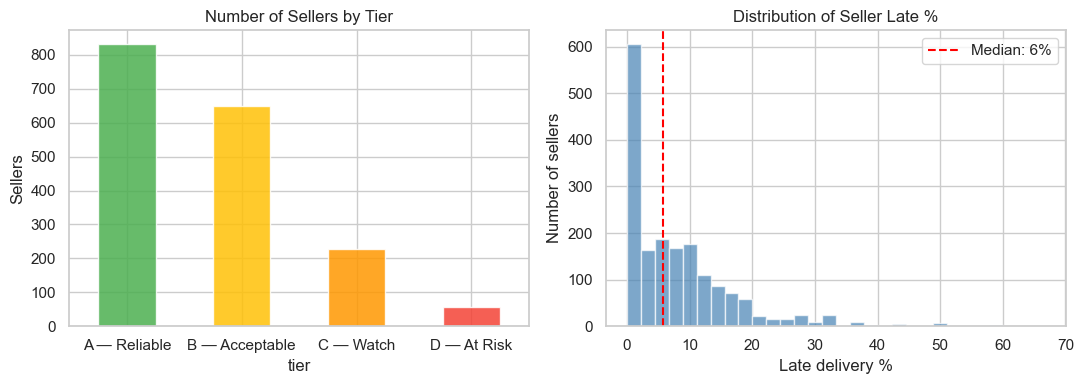

In [6]:
# Visualize tier distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

colors = {'A — Reliable': '#4CAF50', 'B — Acceptable': '#FFC107',
          'C — Watch': '#FF9800', 'D — At Risk': '#F44336'}

tier_counts = seller_stats['tier'].value_counts().sort_index()
tier_counts.plot.bar(ax=ax1, color=[colors[t] for t in tier_counts.index], alpha=0.85)
ax1.set_title('Number of Sellers by Tier')
ax1.set_ylabel('Sellers')
ax1.tick_params(axis='x', rotation=0)

# Late rate distribution
ax2.hist(seller_stats['late_pct'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(seller_stats['late_pct'].median(), color='red', linestyle='--',
            label=f'Median: {seller_stats["late_pct"].median():.0f}%')
ax2.set_title('Distribution of Seller Late %')
ax2.set_xlabel('Late delivery %')
ax2.set_ylabel('Number of sellers')
ax2.legend()

plt.tight_layout()
plt.savefig('../output/02_seller_tiers.png', dpi=150)
plt.show()

## 3. Geography: Seller-to-Customer Distance Effect

In [7]:
# Cross-state vs same-state deliveries
clean['same_state'] = (clean['seller_state'] == clean['customer_state']).astype(int)

geo_comparison = clean.groupby('same_state').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late', 'mean'),
    median_transit_hrs=('hours_carrier_to_customer', 'median')
).round(3)
geo_comparison.index = ['Cross-state', 'Same state']

print('Same-state vs cross-state deliveries:')
print(geo_comparison)
print()
print(f'Cross-state late rate is {geo_comparison.loc["Cross-state","late_rate"]/geo_comparison.loc["Same state","late_rate"]:.1f}x higher')

Same-state vs cross-state deliveries:
             orders  late_rate  median_transit_hrs
Cross-state   60917      0.094               220.7
Same state    34177      0.061                87.8

Cross-state late rate is 1.5x higher


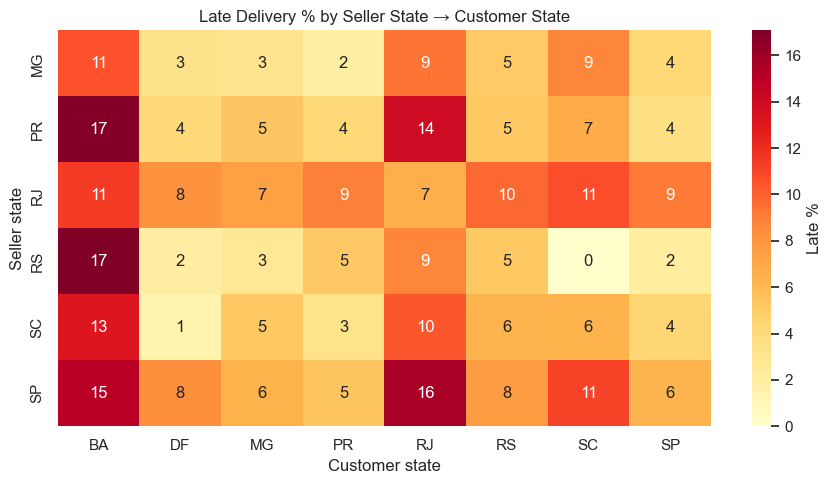

In [8]:
# Heatmap
top_seller_states = clean['seller_state'].value_counts().head(6).index
top_cust_states = clean['customer_state'].value_counts().head(8).index

corridor = (clean[clean['seller_state'].isin(top_seller_states) &
                   clean['customer_state'].isin(top_cust_states)]
    .groupby(['seller_state', 'customer_state'])['is_late']
    .mean()
    .unstack()
    * 100)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(corridor, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Late %'})
ax.set_title('Late Delivery % by Seller State → Customer State')
ax.set_ylabel('Seller state')
ax.set_xlabel('Customer state')
plt.tight_layout()
plt.savefig('../output/02_corridor_heatmap.png', dpi=150)
plt.show()

## 4. Business Impact

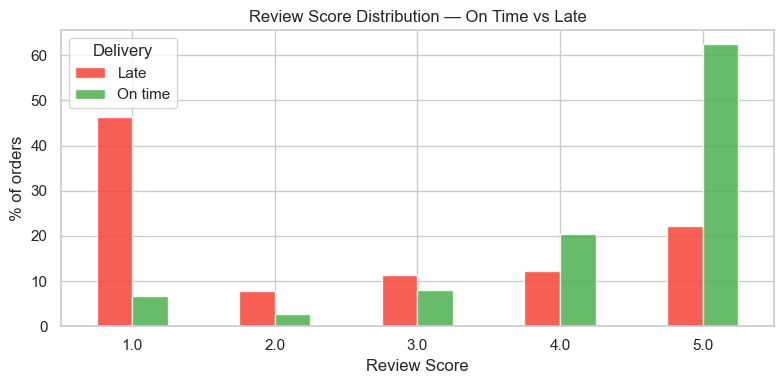

1-star review rate:  Late=46.2%  |  On time=6.6%
Late deliveries are 7.0x more likely to get 1-star


In [9]:
# Review score breakdown by delivery outcome
review_data = abt.dropna(subset=['review_score']).copy()
review_data['delivery_outcome'] = review_data['is_late'].map({0: 'On time', 1: 'Late'})

fig, ax = plt.subplots(figsize=(8, 4))
review_by_outcome = (review_data.groupby(['delivery_outcome', 'review_score'])
    .size()
    .unstack(level=0)
    .apply(lambda x: x / x.sum() * 100))

review_by_outcome.plot.bar(ax=ax, color=['#F44336', '#4CAF50'], alpha=0.85)
ax.set_title('Review Score Distribution — On Time vs Late')
ax.set_xlabel('Review Score')
ax.set_ylabel('% of orders')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Delivery')
plt.tight_layout()
plt.savefig('../output/02_reviews_by_delivery.png', dpi=150)
plt.show()

# Key stat for business case
late_1star = review_data[review_data['is_late']==1]['review_score'].value_counts(normalize=True).get(1, 0)
ontime_1star = review_data[review_data['is_late']==0]['review_score'].value_counts(normalize=True).get(1, 0)
print(f'1-star review rate:  Late={late_1star:.1%}  |  On time={ontime_1star:.1%}')
print(f'Late deliveries are {late_1star/ontime_1star:.1f}x more likely to get 1-star')

In [12]:
# Rough dollar estimate of impact
total_late = abt['is_late'].sum()
avg_order_value = abt['total_price'].mean()

# Conservative assumption: 20% of customers who get a late delivery never reorder
churn_rate_assumption = 0.20
avg_lifetime_orders = 1.4  # marketplace typical, low repeat

lost_revenue_estimate = total_late * churn_rate_assumption * avg_order_value * avg_lifetime_orders

print('Business Impact Estimate')
print(f'Total late deliveries:         {total_late:,}')
print(f'Average order value:           R${avg_order_value:,.2f}')
print(f'Assumed churn from late:       {churn_rate_assumption:.0%}')
print(f'Est. lost lifetime revenue:    R${lost_revenue_estimate:,.0f}')
print()
print('This is a rough estimate')

Business Impact Estimate
Total late deliveries:         7,826
Average order value:           R$137.04
Assumed churn from late:       20%
Est. lost lifetime revenue:    R$300,296

This is a rough estimate


## 5. Key Diagnostic Findings


**1. The transit leg is the bottleneck.** Purchase-to-approval is near-instant for both groups. Seller prep (approval-to-carrier) adds a modest 29 hours for late orders (72h vs 43h). But the carrier-to-customer leg explodes: 574 hours for late orders vs 166 hours for on-time, a difference of 408 hours (~17 days). This stage alone accounts for over 90% of the excess delay. The problem is logistics, not internal processing or seller slowness.

**2. Most sellers are fine; the problem is a long tail.** About 830 sellers fall in the Reliable tier and 645 in Acceptable. Only ~55 sellers (roughly 3% of active sellers) are in the At Risk tier, but they likely account for a disproportionate share of late orders. The median seller late rate is 6%, meaning the typical seller is performing reasonably well, targeted intervention on the worst performers would have outsized impact.

**3. Geography drives late deliveries more than anything else.** The worst corridors all involve shipping to Bahia (BA) or Rio de Janeiro (RJ) as the customer destination. SP sellers shipping to RJ hit a 16% late rate; PR and RS sellers shipping to BA hit 17%. Meanwhile, same-state or nearby-state deliveries (MG-to-MG at 3%, PR-to-PR at 4%) perform significantly better. The pattern is consistent across all seller origins.

**4. Late delivery devastates customer satisfaction.** 46% of late orders receive a 1-star review compared to roughly 6% for on-time orders, a 7-8x multiplier. On-time orders get 5-star reviews 62% of the time; late orders only 22%. This is the strongest single predictor of a bad review in the dataset, stronger than price, product category, or seller rating.

**5. Estimated revenue impact.** With roughly 7,800 late deliveries in the dataset and an average order value around R$120-140, even a conservative 20% churn assumption among affected customers puts estimated lost lifetime revenue in the R$250,000-300,000 range for this period alone. The real number is likely higher once you factor in negative word-of-mouth and reduced platform trust.

---

In [13]:
conn.close()
print('Notebook complete.')

Notebook complete.
